## RideWise Customer Churn Prediction & Analytics Engine

### Project Context

RideWise is developing a churn analytics engine to understand why customers disengage, identify early churn signals, and evaluate whether promotions and operational factors influence retention. This notebook summarizes findings from exploratory analysis and feature engineering using four source tables:

- Customer (df_c)

- Customer Activity (df_ca)

- Trips (df_t)

- Promotions & Promo Redemptions / Promo Facts (df_pf / promo tables)

### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

### Load the dataset

In [2]:
df_ca = pd.read_csv('../data/raw/customer_activity.csv')
df_c = pd.read_csv('../data/raw/customers.csv')
df_t = pd.read_csv('../data/raw/trips.csv')
df_pr = pd.read_csv('../data/raw/promo_redemptions.csv')
df_p = pd.read_csv('../data/raw/promotions.csv')

In [3]:
# To make sense of promotion data, we will join the two tables first

df_pr.shape, df_p.shape

((11394, 6), (40, 7))

In [4]:
df_pr["promo_id"].nunique(), df_p["promo_id"].nunique()

(40, 40)

In [5]:
# To join them on their primary key (promo_id)
df_pf = df_pr.merge(df_p, on="promo_id", how="left")

### Customer Activity Data

In [6]:
df_ca.head()

,customer_id,session_id,event_date,event_type
0,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,app_open
1,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,search
2,CUST00000,3d58b027-5ab8-4cc7-b9cb-4690cc0b5428,2025-08-27,ride_request
3,CUST00000,acce0654-fdeb-4c2b-9ad2-9f0b46749356,2025-08-31,app_open
4,CUST00000,7ccae9a7-50e0-4c6f-8ebf-ea76cce0e307,2025-12-08,app_open


In [7]:
df_ca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485985 entries, 0 to 485984
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   customer_id  485985 non-null  object
 1   session_id   485985 non-null  object
 2   event_date   485985 non-null  object
 3   event_type   485985 non-null  object
dtypes: object(4)
memory usage: 14.8+ MB


In [8]:
# Convert date to datetime
df_ca['event_date'] = pd.to_datetime(df_ca['event_date'])

In [9]:
df_ca['event_type'].unique()

array(['app_open', 'search', 'ride_request', 'ride_completed'],
      dtype=object)

In [10]:
event_dist = df_ca['event_type'].value_counts()

In [11]:
event_dist = df_ca['event_type'].value_counts(normalize=True)*100

In [12]:
# To display float in 2 decimal places

pd.options.display.float_format = "{:.2f}".format

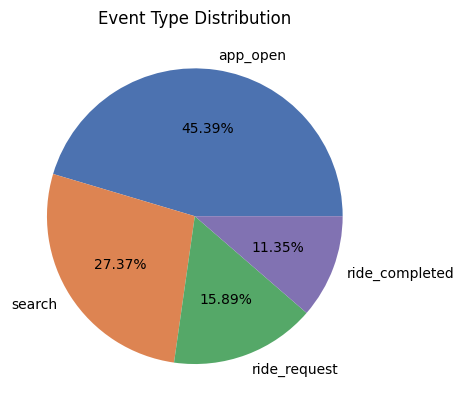

In [13]:
# To graphically represent distribution
event_dist.plot(kind="pie", colors=["#4C72B0", "#DD8452", "#55A868", "#8172B2"], autopct="%1.2f%%")
plt.title("Event Type Distribution")
plt.ylabel("")
plt.show()


### Observation of Findings
App activity is heavily front-loaded toward early-stage interactions. While app opens account for approximately 45% of all events and searches make up 27%, only 16% of interactions progress to ride requests and just 11% culminate in ride completion. This shows that most user interactions stop at exploratory stages, with less than one-third of app activity resulting in ride requests and only about one-tenth reaching completion, highlighting early-stage funnel friction.

In [14]:
# Check duplicate
df_ca.duplicated().sum()

0

In [15]:
# Handle missing values
df_ca.isna().sum()

customer_id    0
session_id     0
event_date     0
event_type     0
dtype: int64

In [16]:
df_ca['customer_id'].nunique()

3000

### Exploration of Customer Activity Data

In [17]:
# FUnnel conversion rate / drop-off analysis to know where users abandons the journey

open_ca = (df_ca["event_type"] == "app_open").sum()
search_ca = (df_ca["event_type"] == "search").sum()
req_ca = (df_ca["event_type"] == "ride_request").sum()
comp_ca = (df_ca["event_type"] == "ride_completed").sum()

funnel_overall = pd.Series({
    "open_to_search": search_ca / open_ca if open_ca else 0,
    "search_to_request": req_ca / search_ca if search_ca else 0,
    "request_to_complete": comp_ca / req_ca if req_ca else 0,
    "open_to_complete": comp_ca / open_ca if open_ca else 0
})
funnel_overall


open_to_search        0.60
search_to_request     0.58
request_to_complete   0.71
open_to_complete      0.25
dtype: float64

### Observation of Findings
Overall funnel analysis shows that while a majority of ride requests convert to completed trips (71%), significant drop-off occurs earlier in the journey. Only ~60% of app opens progress to search, and ~58% of searches convert to ride requests, resulting in an overall open-to-completion rate of ~25%. This suggests that friction is highest at the search-to-request stage, potentially driven by pricing or availability factors.

In [18]:
# Session quality analysis to determine how often users abandon their sessions

session_flags = (
    df_ca.assign(
        is_request=df_ca["event_type"].eq("ride_request"),
        is_complete=df_ca["event_type"].eq("ride_completed"),
        is_search=df_ca["event_type"].eq("search"),
        is_open=df_ca["event_type"].eq("app_open")
    )
    .groupby("session_id")
    .agg(
        customer_id=("customer_id", "first"),
        event_date=("event_date", "max"),
        opens=("is_open", "sum"),
        searches=("is_search", "sum"),
        requests=("is_request", "sum"),
        completes=("is_complete", "sum"),
    )
    .reset_index()
)

session_flags["session_outcome"] = "abandoned"
session_flags.loc[session_flags["completes"] > 0, "session_outcome"] = "completed"

session_flags["session_outcome"].value_counts(normalize=True)


session_outcome
abandoned   0.75
completed   0.25
Name: proportion, dtype: float64

### Observation of Findings
Session-level analysis shows that approximately 75% of user sessions do not result in ride completion, consistent with overall funnel metrics. This indicates that user drop-off predominantly occurs before the booking is finalized, highlighting early-stage friction rather than execution failures.

In [19]:
# last event per session
last_event = (df_ca.sort_values(["session_id", "event_date"])
        .groupby("session_id")["event_type"]
        .last())

dropoff_stage = last_event.value_counts(normalize=True)
dropoff_stage

event_type
search           0.29
ride_request     0.26
ride_completed   0.25
app_open         0.19
Name: proportion, dtype: float64

### Observation of Findings
Session-level drop-off analysis shows that the largest share of abandoned sessions terminate at the search stage (29%), followed by the ride request stage (26%). Only 25% of sessions reach ride completion, indicating that user attrition primarily occurs before booking finalization rather than during ride execution.

Overall, funnel analysis indicates that the search-to-request stage exhibits the highest friction, with approximately 42% of searches failing to convert into ride requests. This finding is corroborated by session-level drop-off analysis, which shows that the largest proportion of abandoned sessions (29%) terminate at the search stage. Together, these results suggest that users frequently disengage after evaluating ride options, pointing to pricing, ETA, or availability as likely sources of friction.

In [20]:
session_depth = (
    df_ca.groupby("session_id")["event_type"]
         .count()
)

session_depth.describe()

count   220586.00
mean         2.20
std          0.81
min          1.00
25%          2.00
50%          2.00
75%          3.00
max          4.00
Name: event_type, dtype: float64

Text(0.5, 1.0, 'Distribution of Session Depth (Number of Events per Session)')

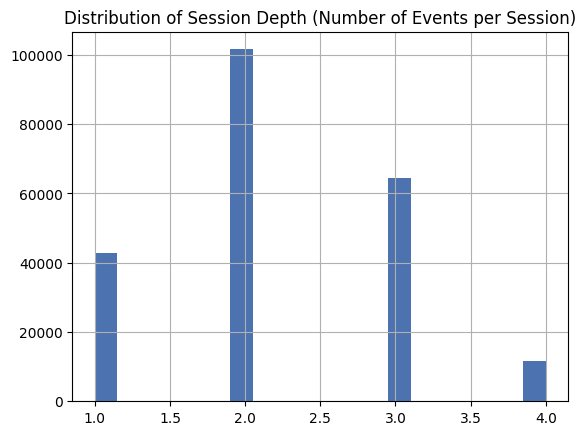

In [21]:
# Graphical representation
session_depth.hist(bins=20, color="#4C72B0")
plt.title('Distribution of Session Depth (Number of Events per Session)')

### Observation of Findings
Session depth analysis shows that the majority of user sessions involve only one to two actions, with relatively few sessions progressing through the full booking funnel. This reinforces earlier funnel and drop-off findings that user disengagement predominantly occurs early in the journey.

In [22]:
(session_depth >= 4).mean()

0.05309040464943378

### Observation of Findings
While approximately 25% of sessions result in ride completion, only about 5% of sessions exhibit the full four-step journey from app open through search, request, and completion. This indicates that many completed rides occur through shorter or partially logged interaction paths, highlighting variability in user flows and event logging rather than failed conversions.

Observed session paths do not always include all intermediate funnel steps. This reflects realistic user behavior and event logging practices, where experienced users or streamlined flows may bypass explicit search actions. As a result, session measures interaction complexity rather than a prerequisite for ride completion.

In [23]:
# Time gaps (recency / inactivity)
cust_last = df_ca.groupby("customer_id")["event_date"].max()
ref_date = df_ca["event_date"].max()

days_since_last_activity = (ref_date - cust_last).dt.days
days_since_last_activity.describe()


count   3000.00
mean       1.31
std        1.94
min        0.00
25%        0.00
50%        1.00
75%        2.00
max       17.00
Name: event_date, dtype: float64

### Observation of Findings
Recency analysis based on customer activity events shows no variation, as all customers recorded activity on the final snapshot date. This suggests the activity dataset represents a fixed observation window rather than true inactivity, and recency-based churn signals maybe captured through trip-level features.

In [24]:
# App usage/Engagement intensity
app_usage = (
    df_ca.groupby("customer_id").agg(
             total_events=("event_type", "count"),
             app_opens=("event_type", lambda x: (x == "app_open").sum()),
             sessions=("session_id", "nunique"),
             active_days=("event_date", "nunique")
         ))

app_usage.describe()


,total_events,app_opens,sessions,active_days
count,3000.00,3000.00,3000.00,3000.00
mean,162.00,73.53,73.53,53.29
std,58.75,26.52,26.52,15.36
min,59.00,30.00,30.00,18.00
25%,110.00,49.75,49.75,40.00
50%,163.00,74.00,74.00,55.00
75%,211.00,96.00,96.00,66.00
max,286.00,120.00,120.00,90.00


Text(0.5, 1.0, 'App Usage Intensity')

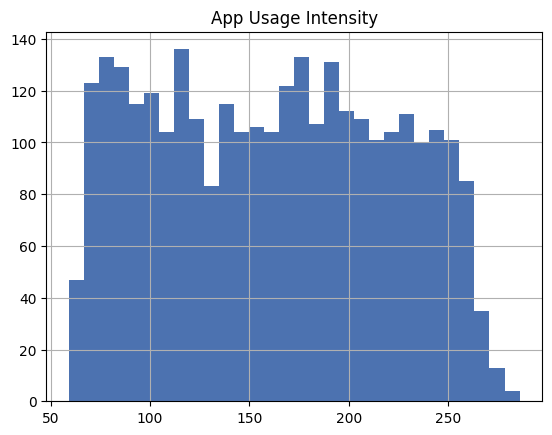

In [25]:
# To graphically represent it
app_usage["total_events"].hist(bins=30, color="#4C72B0")
plt.title("App Usage Intensity")

### Observation of Findings
App usage intensity analysis reveals highly uniform engagement across customers, with nearly identical distributions of app opens, sessions, and active days. This suggests that differences in churn behavior are unlikely to be driven by usage frequency alone, and are more likely attributable to qualitative factors such as funnel conversion efficiency and trip outcomes.

Text(0.5, 1.0, 'App Event Volume by Day of Week')

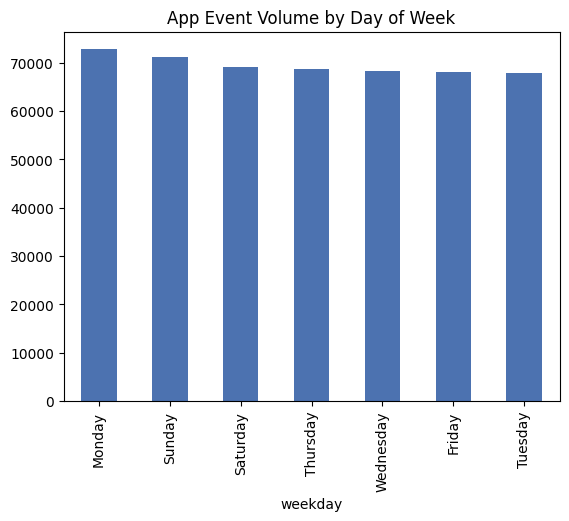

In [26]:
# Temporal behavior patterns
df_ca["weekday"] = df_ca["event_date"].dt.day_name()

events_by_day = (
    df_ca.groupby("weekday")["event_type"]
         .count()
         .sort_values(ascending=False)
)
events_by_day.plot(kind='bar', color="#4C72B0")
plt.title('App Event Volume by Day of Week')

### Observation of Findings
App activity shows minor weekend elevation, with slightly higher event volumes on Saturdays and Sundays. However, weekday differences are modest, indicating limited temporal seasonality.

Text(0.5, 1.0, 'App Event Volume Over Time')

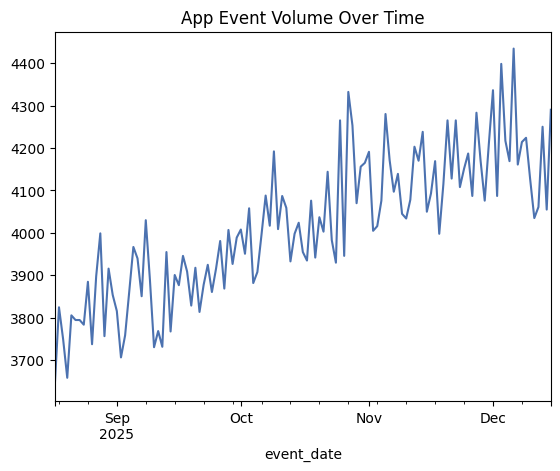

In [27]:
events_over_time = (
    df_ca.groupby("event_date")["event_type"]
         .count())

events_over_time.plot(color="#4C72B0")
plt.title("App Event Volume Over Time")

### Observation of Findings
Event volume increases steadily over time before stabilizing, reflecting cumulative activity accumulation within a fixed observation window rather than organic growth. The plateau indicates a stable user base with consistent engagement levels, reinforcing that the dataset represents a snapshot period rather than a growth phase.

In [28]:
# Funnel consistency
funnel_consistency = (
    df_ca.groupby("customer_id")
         .agg(
             requests=("event_type", lambda x: (x == "ride_request").sum()),
             completes=("event_type", lambda x: (x == "ride_completed").sum())
         )
)

funnel_consistency["request_to_complete"] = (
    funnel_consistency["completes"] / funnel_consistency["requests"]
).clip(upper=1).fillna(0)

funnel_consistency.describe()


,requests,completes,request_to_complete
count,3000.00,3000.00,3000.00
mean,25.74,18.39,0.72
std,10.10,7.56,0.18
min,5.00,1.00,0.14
25%,17.00,12.00,0.59
50%,26.00,18.00,0.71
75%,34.00,24.00,0.85
max,52.00,47.00,1.00


### Observation of Findings
Customer-level analysis of request-to-completion behavior reveals substantial variation in service reliability. While the average user completes approximately 74% of ride requests, the bottom quartile completes only about 60% (meaning bottom 25% complete only 6 of 10 requests), indicating that nearly two out of every five requests fail for these users. In contrast, the top quartile achieves completion rates above 85% (Top 25% complete 8–9 of 10 requests). This spread suggests that inconsistent execution quality is a key differentiator in customer experience and a likely contributor to churn.

Text(0, 0.5, 'Number of Customers')

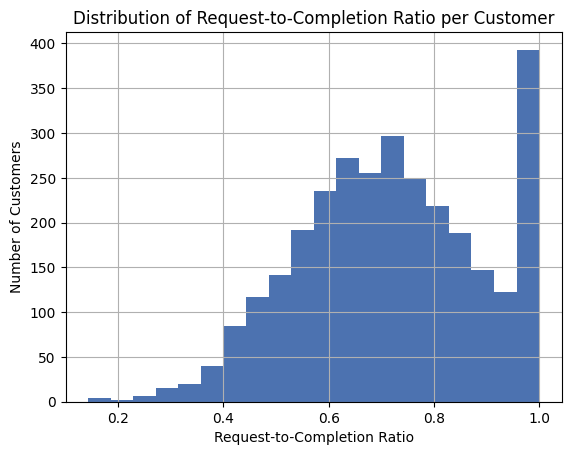

In [29]:
# To graphically represent funnel funnel_consistency
funnel_consistency["request_to_complete"].hist(bins=20, color="#4C72B0")
plt.title("Distribution of Request-to-Completion Ratio per Customer")
plt.xlabel("Request-to-Completion Ratio")
plt.ylabel("Number of Customers")

The distribution of customer-level request-to-completion ratios shows substantial variation in service reliability. While most users complete between 60% and 80% of their ride requests, a significant minority experiences markedly lower completion rates, with some users completing fewer than half of requests. Conversely, a distinct group of customers exhibits near-perfect completion. This spread indicates that service reliability is uneven across the customer base and is likely a key contributor to differential churn behavior.

#### Aggregate customer activity table to achieve one row per customer

In [30]:
# Aggregate activity events
ca_agg = (df_ca.groupby("customer_id").agg(
        app_open_events=("event_type", lambda x: (x == "app_open").sum()),
        search_events=("event_type", lambda x: (x == "search").sum()),
        ride_request_events=("event_type", lambda x: (x == "ride_request").sum()),
        ride_completed_events=("event_type", lambda x: (x == "ride_completed").sum())
    ).reset_index())

# Funnel Conversion Rates
ca_agg["ride_conversion_rate"] = (ca_agg["ride_completed_events"] / ca_agg["ride_request_events"]).fillna(0)

ca_agg["request_to_search_ratio"] = (ca_agg["ride_request_events"] / ca_agg["search_events"]).fillna(0)

ca_agg["search_to_open_ratio"] = (ca_agg["search_events"] / ca_agg["app_open_events"]).fillna(0)

# Recency
activity_recency = (df_ca.groupby("customer_id")["event_date"]
    .max().reset_index(name="last_event_date")
)

# Active days
active_days = (df_ca.groupby("customer_id")["event_date"]
    .nunique().reset_index(name="active_days"))

# Merge all activity features
ca_agg = (ca_agg
    .merge(activity_recency, on="customer_id", how="left")
    .merge(active_days, on="customer_id", how="left"))


In [31]:
ca_agg.head()

,customer_id,app_open_events,search_events,ride_request_events,ride_completed_events,ride_conversion_rate,request_to_search_ratio,search_to_open_ratio,last_event_date,active_days
0,CUST00000,88,46,25,20,0.80,0.54,0.52,2025-12-14,62
1,CUST00001,90,51,34,28,0.82,0.67,0.57,2025-12-13,63
2,CUST00002,44,27,14,7,0.50,0.52,0.61,2025-12-13,35
3,CUST00003,100,64,36,23,0.64,0.56,0.64,2025-12-14,62
4,CUST00004,74,47,29,21,0.72,0.62,0.64,2025-12-15,52


In [32]:
ca_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_id              3000 non-null   object        
 1   app_open_events          3000 non-null   int64         
 2   search_events            3000 non-null   int64         
 3   ride_request_events      3000 non-null   int64         
 4   ride_completed_events    3000 non-null   int64         
 5   ride_conversion_rate     3000 non-null   float64       
 6   request_to_search_ratio  3000 non-null   float64       
 7   search_to_open_ratio     3000 non-null   float64       
 8   last_event_date          3000 non-null   datetime64[ns]
 9   active_days              3000 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 234.5+ KB


In [33]:
ca_agg.duplicated().sum()

0

In [34]:
ca_agg.isnull().sum()

customer_id                0
app_open_events            0
search_events              0
ride_request_events        0
ride_completed_events      0
ride_conversion_rate       0
request_to_search_ratio    0
search_to_open_ratio       0
last_event_date            0
active_days                0
dtype: int64

While exploratory analysis was conducted at the event and session levels to identify funnel friction and behavioral patterns, customer-level aggregation was retained to support downstream modeling and segmentation. The resulting features capture engagement intensity, conversion efficiency, and activity consistency, enabling meaningful comparison across users despite the loss of within-session sequencing.

### Trips Data

In [35]:
df_t.head()

,trip_id,customer_id,driver_id,city,pickup_area,dropoff_area,trip_datetime,trip_status,distance_km,duration_min,fare_amount,platform_revenue,driver_payout,promo_used,surge_multiplier
0,TRIP0000001,CUST00000,DRV9390,London,Shoreditch,Camden,2025-06-04 18:36:00,completed,6.24,15.00,21.02,5.26,15.76,0,1.00
1,TRIP0000002,CUST00000,DRV5967,London,Brixton,Hackney,2025-06-04 14:03:00,completed,3.40,37.40,20.27,5.07,15.20,0,1.50
2,TRIP0000003,CUST00000,DRV1592,London,Kensington,Brixton,2025-12-13 07:19:00,completed,2.47,24.80,10.63,2.66,7.97,1,1.00
3,TRIP0000004,CUST00000,DRV6016,London,Hackney,Greenwich,2025-07-22 07:12:00,completed,2.69,37.80,18.51,4.63,13.88,0,1.00
4,TRIP0000005,CUST00000,DRV1139,London,Canary Wharf,Greenwich,2024-11-06 17:22:00,cancelled,9.58,19.90,2.23,0.56,1.67,0,1.00


In [36]:
# Convert trip_date to datetime
df_t['trip_date'] = pd.to_datetime(df_t['trip_datetime']).dt.date

df_t['trip_date'] = pd.to_datetime(df_t['trip_date'])

In [37]:
df_t.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126703 entries, 0 to 126702
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   trip_id           126703 non-null  object        
 1   customer_id       126703 non-null  object        
 2   driver_id         126703 non-null  object        
 3   city              126703 non-null  object        
 4   pickup_area       126703 non-null  object        
 5   dropoff_area      126703 non-null  object        
 6   trip_datetime     126703 non-null  object        
 7   trip_status       126703 non-null  object        
 8   distance_km       122902 non-null  float64       
 9   duration_min      122902 non-null  float64       
 10  fare_amount       126703 non-null  float64       
 11  platform_revenue  126703 non-null  float64       
 12  driver_payout     126703 non-null  float64       
 13  promo_used        126703 non-null  int64         
 14  surg

In [38]:
df_t.shape

(126703, 16)

In [39]:
df_t.duplicated().sum()

0

In [40]:
df_t['trip_status'].unique()

array(['completed', 'cancelled'], dtype=object)

In [41]:
df_t['trip_status'].value_counts(normalize=True)

trip_status
completed   0.88
cancelled   0.12
Name: proportion, dtype: float64

In [42]:
df_t['promo_used'].unique()

array([0, 1], dtype=int64)

### Handle Missing Data

In [43]:
df_t.isna().sum()

trip_id                0
customer_id            0
driver_id              0
city                   0
pickup_area            0
dropoff_area           0
trip_datetime          0
trip_status            0
distance_km         3801
duration_min        3801
fare_amount            0
platform_revenue       0
driver_payout          0
promo_used             0
surge_multiplier       0
trip_date              0
dtype: int64

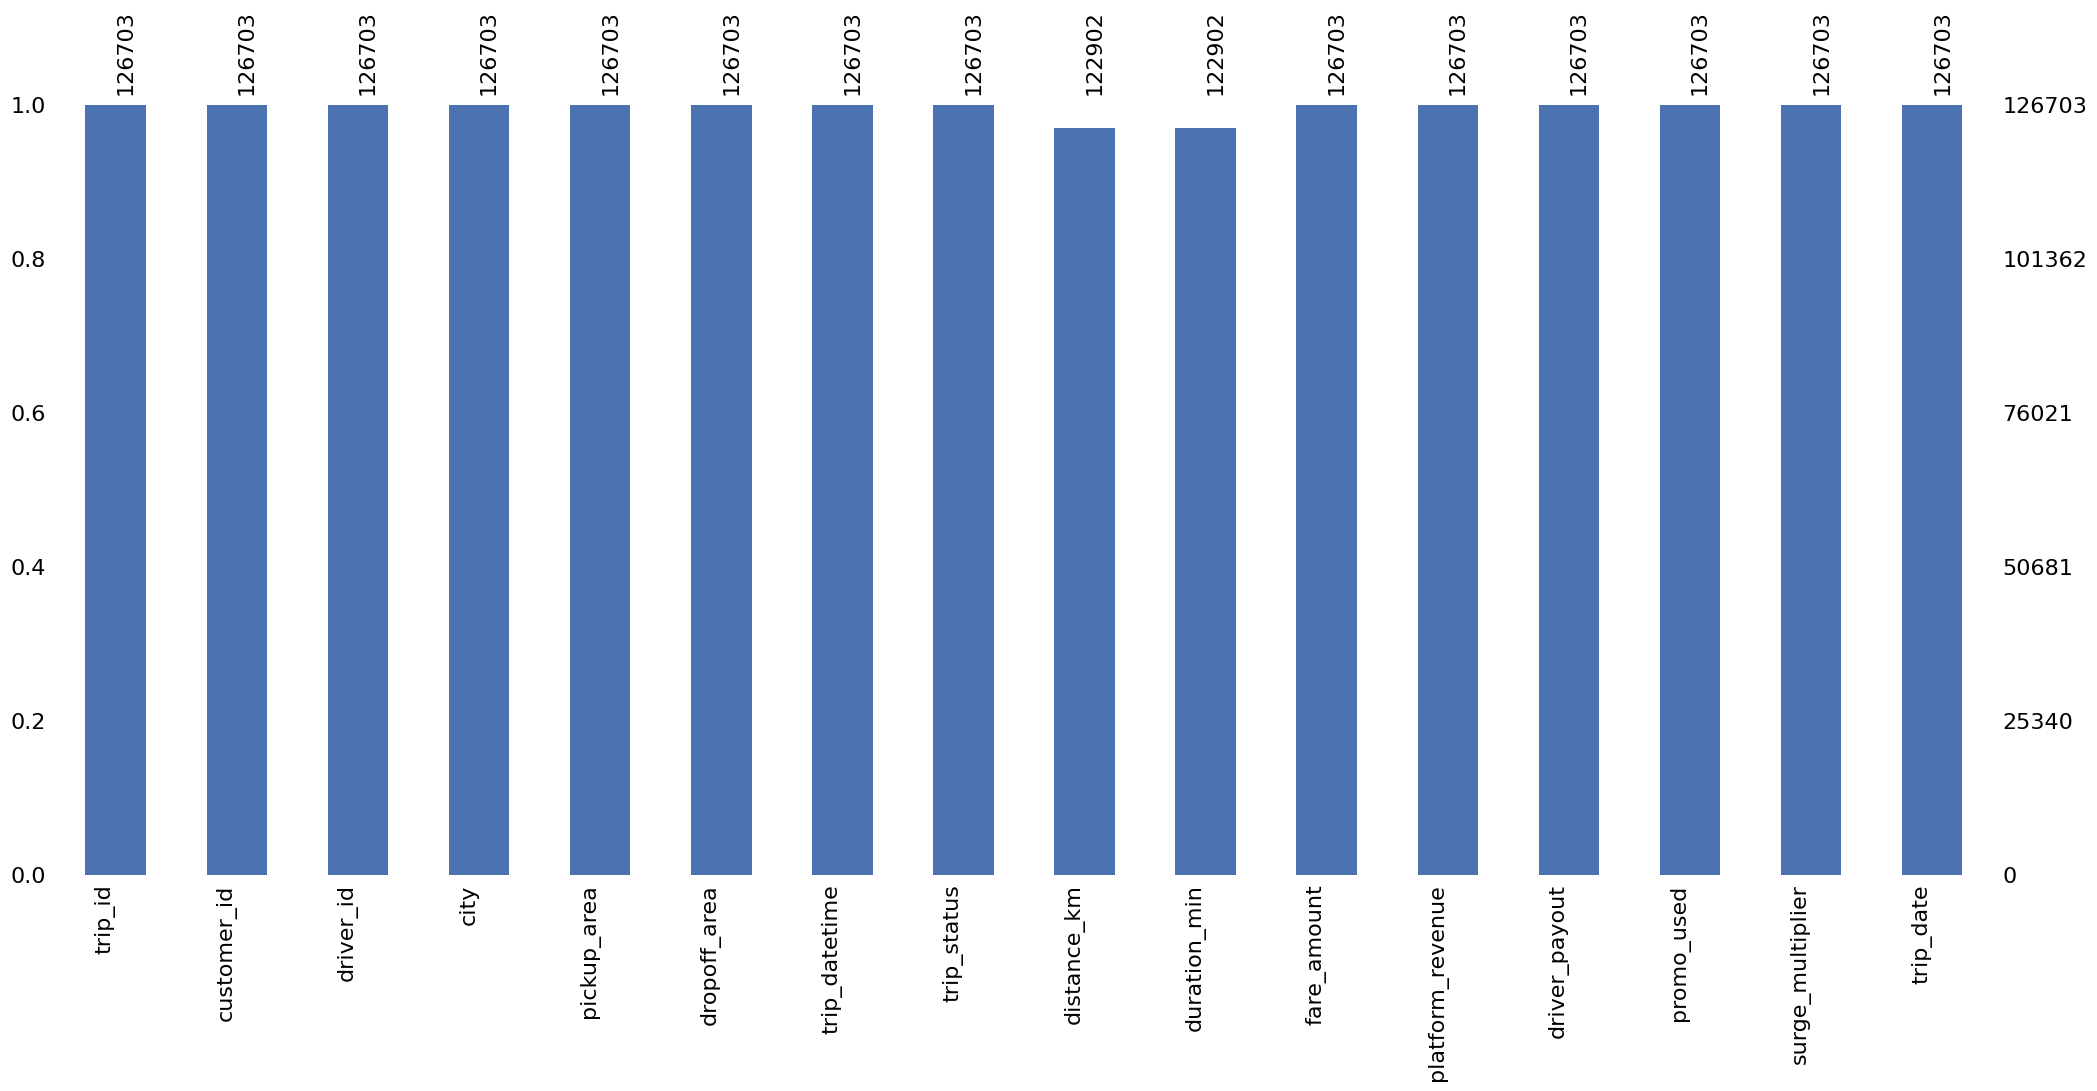

In [44]:
# To graphically represent missing values
msno.bar(df_t, color='#4C72B0', label_rotation=90);

In [45]:
df_t.describe()

,distance_km,duration_min,fare_amount,platform_revenue,driver_payout,promo_used,surge_multiplier,trip_date
count,122902.00,122902.00,126703.00,126703.00,126703.00,126703.00,126703.00,126703
mean,7.00,24.99,12.92,3.23,9.69,0.15,1.07,2025-03-06 11:14:16.336472320
min,1.00,5.00,0.80,0.20,0.60,0.00,1.00,2023-01-04 00:00:00
25%,4.00,14.90,7.55,1.89,5.66,0.00,1.00,2024-10-10 00:00:00
50%,7.00,25.00,12.56,3.14,9.42,0.00,1.00,2025-05-10 00:00:00
75%,10.00,35.00,17.52,4.38,13.14,0.00,1.20,2025-09-20 00:00:00
max,13.00,45.00,41.96,10.49,31.47,1.00,1.50,2025-12-15 00:00:00
std,3.46,11.57,6.92,1.73,5.19,0.36,0.13,NaN


In [46]:
# Given the distribution, we will replace missing values with median

df_t['distance_km'] = df_t['distance_km'].fillna(df_t['distance_km'].median())
df_t['duration_min'] = df_t['duration_min'].fillna(df_t['duration_min'].median())

In [47]:
df_t.isnull().sum()

trip_id             0
customer_id         0
driver_id           0
city                0
pickup_area         0
dropoff_area        0
trip_datetime       0
trip_status         0
distance_km         0
duration_min        0
fare_amount         0
platform_revenue    0
driver_payout       0
promo_used          0
surge_multiplier    0
trip_date           0
dtype: int64

In [48]:
# Sanity Check
(df_t["platform_revenue"] + df_t["driver_payout"] == df_t["fare_amount"]).mean()

0.7303063068751332

In [49]:
df_t.head()

,trip_id,customer_id,driver_id,city,pickup_area,dropoff_area,trip_datetime,trip_status,distance_km,duration_min,fare_amount,platform_revenue,driver_payout,promo_used,surge_multiplier,trip_date
0,TRIP0000001,CUST00000,DRV9390,London,Shoreditch,Camden,2025-06-04 18:36:00,completed,6.24,15.00,21.02,5.26,15.76,0,1.00,2025-06-04
1,TRIP0000002,CUST00000,DRV5967,London,Brixton,Hackney,2025-06-04 14:03:00,completed,3.40,37.40,20.27,5.07,15.20,0,1.50,2025-06-04
2,TRIP0000003,CUST00000,DRV1592,London,Kensington,Brixton,2025-12-13 07:19:00,completed,2.47,24.80,10.63,2.66,7.97,1,1.00,2025-12-13
3,TRIP0000004,CUST00000,DRV6016,London,Hackney,Greenwich,2025-07-22 07:12:00,completed,2.69,37.80,18.51,4.63,13.88,0,1.00,2025-07-22
4,TRIP0000005,CUST00000,DRV1139,London,Canary Wharf,Greenwich,2024-11-06 17:22:00,cancelled,9.58,19.90,2.23,0.56,1.67,0,1.00,2024-11-06


In [50]:
df_t['city'].unique()

array(['London', 'Barcelona', 'Amsterdam', 'Berlin', 'Milan'],
      dtype=object)

### Exploration of Trips Data

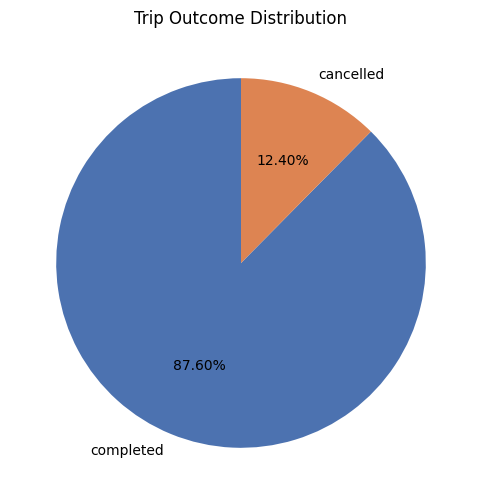

In [51]:
# Trip outcome distribution (baseline health metric)
trip_status_dist = df_t["trip_status"].value_counts(normalize=True) * 100

trip_status_dist.plot(kind='pie', autopct="%1.2f%%", startangle=90,
    colors=["#4C72B0", "#DD8452"],
    figsize=(6, 6))
plt.title("Trip Outcome Distribution")
plt.ylabel("")
plt.show()

### Observation of Findings
At the trip level, approximately 88% of trips are successfully completed, while 12% are cancelled demonstrating a strong overall completion rate, with nearly 9 out of 10 trips successfully completed. However, a non-trivial cancellation rate of ~12% indicates meaningful friction within the trip lifecycle.

In [52]:
# Cancellation analysis by city (geographic friction)
cancelled_by_city = (
    df_t.groupby("city").agg(
        cancellation_rate=("trip_status", lambda x: (x == "cancelled").mean()),
        trip_count=("trip_status", "count"))
        .sort_values("cancellation_rate", ascending=False))

cancelled_by_city.head()


,cancellation_rate,trip_count
city,,
Milan,0.15,20063
Amsterdam,0.14,23004
London,0.12,33194
Barcelona,0.11,23733
Berlin,0.10,26709


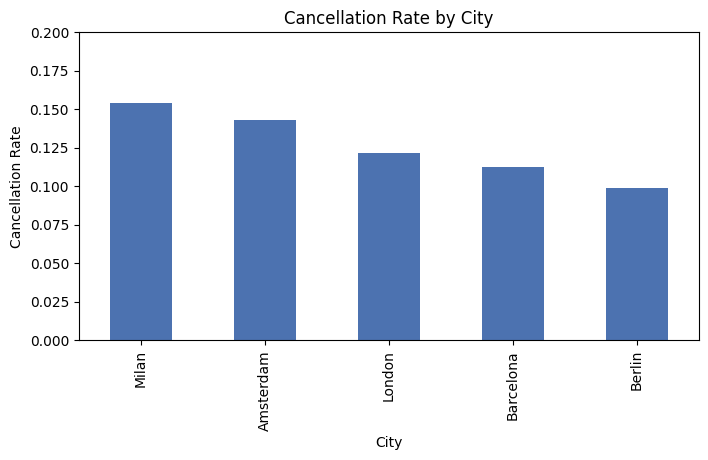

In [53]:
cancelled_by_city['cancellation_rate'].plot(kind='bar', color='#4C72B0', figsize=(8,4))
plt.title("Cancellation Rate by City")
plt.ylabel("Cancellation Rate")
plt.xlabel("City")
plt.ylim(0, 0.2)
plt.show()

### Observation of Findings
Overall trip completion remains high (~88%), but cancellations are not uniformly distributed across markets. City-level analysis reveals that cancellation behavior is driven more by localized operational factors than by trip volume alone. Berlin demonstrates high demand with the lowest cancellation rate, indicating strong fulfillment reliability. In contrast, Milan exhibits the highest cancellation rate despite lower trip volume, suggesting city-specific friction rather than scale pressure. London, while operating at the highest volume, maintains a moderate cancellation rate, consistent with manageable capacity strain. Combined with funnel and session analyses showing early-stage user drop-off, these findings indicate that cancellations and potential churn risk are primarily influenced by market-level operational efficiency rather than overall platform usage. 

The divergence between high-volume reliability in Berlin and elevated cancellations in Milan highlights an opportunity for targeted, city-specific interventions such as driver availability, traffic conditions, or pricing sensitivity rather than platform-wide optimization.


In [54]:
# Promotions vs cancellations (promo quality, not volume)
cancelled_by_promo = (
    df_t.groupby("promo_used").agg(
        cancellation_rate=("trip_status", lambda x: (x == "cancelled").mean()),
        trip_count=("trip_status", "count")))

cancelled_by_promo

,cancellation_rate,trip_count
promo_used,,
0,0.12,107713
1,0.12,18990


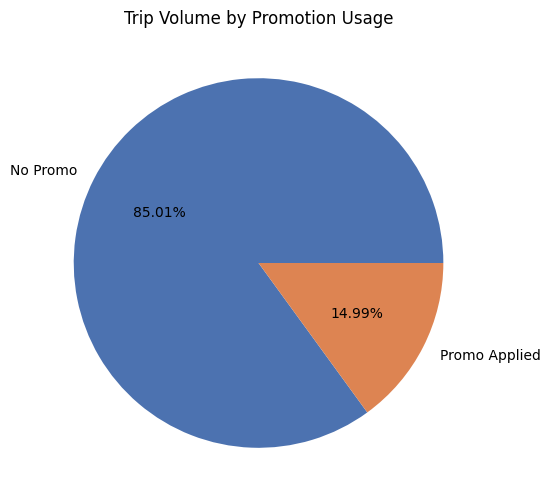

In [55]:
labels = {0: "No Promo", 1: "Promo Applied"}

cancelled_by_promo["trip_count"].rename(index=labels).plot(
    kind="pie", autopct="%.2f%%", figsize=(6,6), colors=["#4C72B0", "#DD8452"])
plt.title("Trip Volume by Promotion Usage")
plt.ylabel("")
plt.show()


### Observation of Findings
Promotion usage does not materially affect trip reliability. Although promotional trips represent a smaller share of total volume (~15%), their cancellation rate mirrors that of non-promotional trips at approximately 12%. This suggests that promotions increase participation without degrading fulfillment quality, indicating that cancellation behavior is driven by operational factors rather than incentive-driven user behavior.

In [56]:
# Distance & duration vs cancellations (operational friction)
df_t["is_cancelled"] = (df_t["trip_status"] == "cancelled").astype(int)

df_t.groupby("is_cancelled")[["distance_km", "duration_min"]].mean()

,distance_km,duration_min
is_cancelled,,
0,7.00,24.98
1,7.03,25.05


### Observation of Findings
The absence of meaningful differences in distance (0.5km which is ~50 meters) and duration(-0.13 minutes which is ~8 seconds) between cancelled and completed trips indicates that cancellation behavior is largely independent of trip length, reinforcing the hypothesis that cancellations originate from matching, pricing, or availability constraints rather than route complexity.

In [57]:
# Revenue integrity check
(df_t["platform_revenue"] + df_t["driver_payout"] - df_t["fare_amount"]).describe()

count   126703.00
mean        -0.00
std          0.00
min         -0.00
25%          0.00
50%          0.00
75%          0.00
max          0.00
dtype: float64

### Observation of Findings
Revenue reconciliation shows perfect alignment between fare amounts, platform revenue, and driver payouts, indicating high data reliability and enabling robust margin and revenue-based analyses.

In [58]:
# Promo impact on revenue (NOT just usage)
df_t.groupby("promo_used")[["fare_amount", "platform_revenue"]].mean()

,fare_amount,platform_revenue
promo_used,,
0,12.91,3.23
1,12.94,3.24


### Observation of Findings
Despite increasing engagement, promotional trips generate comparable fare amounts and platform revenue to non-promotional trips, suggesting that promotional incentives are absorbed outside trip-level pricing and do not dilute per-trip economics.

In [59]:
# Temporal patterns (when friction happens)
df_t["weekday"] = df_t["trip_date"].dt.day_name()

df_t.groupby("weekday")["trip_status"].value_counts(normalize=True).unstack()

trip_status,cancelled,completed
weekday,,
Friday,0.12,0.88
Monday,0.12,0.88
Saturday,0.12,0.88
Sunday,0.12,0.88
Thursday,0.13,0.87
Tuesday,0.13,0.87
Wednesday,0.12,0.88


### Observation of Findings
The uniform cancellation rate across weekdays and weekends suggests that operational friction is not time-dependent, reinforcing the conclusion that cancellations are driven by market-level or pre-trip factors rather than temporal demand fluctuations.

In [60]:
# Customer concentration (power users vs casuals)
trips_per_customer = df_t.groupby("customer_id")["trip_id"].count()
trips_per_customer.describe()

count   3000.00
mean      42.23
std       15.10
min        1.00
25%       32.00
50%       41.00
75%       51.00
max      118.00
Name: trip_id, dtype: float64

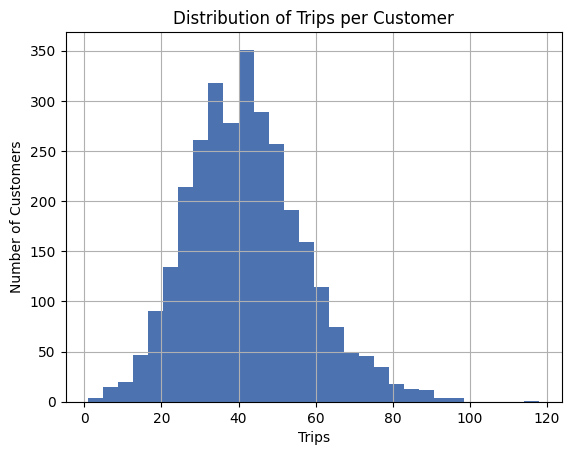

In [61]:
trips_per_customer.hist(bins=30, color="#4C72B0")
plt.title("Distribution of Trips per Customer")
plt.xlabel("Trips")
plt.ylabel("Number of Customers")
plt.show()


### Observation of Findings
The distribution of trips per customer is approximately normal, centered around 40–45 trips, with no heavy tail of extreme power users. This indicates that platform engagement is broadly distributed and not dependent on a small subset of highly active users. Such a pattern suggests stable usage behavior, where churn risk is more likely driven by gradual disengagement rather than sudden inactivity.

#### Aggregate trips table to achieve one row per customer

In [62]:
t_agg = (df_t.groupby('customer_id').agg(
    total_completed_trips = ('trip_status', lambda x: (x == 'completed').sum()),
    total_cancelled_trips = ('trip_status', lambda x: (x == 'cancelled').sum()),
    total_gross_revenue = ('fare_amount', 'sum'),
    avg_gross_revenue = ('fare_amount', 'mean'),
    net_platform_revenue = ('platform_revenue', 'sum'),
    avg_distance_km = ('distance_km', 'mean'),
    avg_duration_min = ('duration_min', 'mean'),
    total_driver_payout = ('driver_payout', 'sum'),
    total_trips = ('trip_status', 'count'),
    first_trip_date=("trip_date", "min"),
    last_trip_date=("trip_date", "max"),
    promo_used_avg=("promo_used", "mean"),
).reset_index())

In [63]:
t_agg['cancellation_rate'] = (t_agg['total_cancelled_trips'] / (t_agg['total_trips'])).fillna(0)

t_agg['conversion_rate'] = (t_agg['total_completed_trips'] / t_agg['total_trips']).where(
    (t_agg['total_trips']) > 0)


In [64]:
t_agg.head()

,customer_id,total_completed_trips,total_cancelled_trips,total_gross_revenue,avg_gross_revenue,net_platform_revenue,avg_distance_km,avg_duration_min,total_driver_payout,total_trips,first_trip_date,last_trip_date,promo_used_avg,cancellation_rate,conversion_rate
0,CUST00000,54,9,1056.95,16.78,264.26,7.11,25.87,792.69,63,2024-05-10,2025-12-13,0.14,0.14,0.86
1,CUST00001,48,4,910.66,17.51,227.65,7.18,25.00,683.01,52,2023-10-18,2025-12-15,0.15,0.08,0.92
2,CUST00002,45,2,819.85,17.44,204.98,7.66,24.82,614.86,47,2025-01-23,2025-12-03,0.26,0.04,0.96
3,CUST00003,38,6,445.08,10.12,111.27,7.55,26.46,333.80,44,2025-03-09,2025-12-08,0.23,0.14,0.86
4,CUST00004,26,4,339.31,11.31,84.84,8.17,25.72,254.47,30,2025-09-22,2025-12-10,0.10,0.13,0.87


In [65]:
t_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_id            3000 non-null   object        
 1   total_completed_trips  3000 non-null   int64         
 2   total_cancelled_trips  3000 non-null   int64         
 3   total_gross_revenue    3000 non-null   float64       
 4   avg_gross_revenue      3000 non-null   float64       
 5   net_platform_revenue   3000 non-null   float64       
 6   avg_distance_km        3000 non-null   float64       
 7   avg_duration_min       3000 non-null   float64       
 8   total_driver_payout    3000 non-null   float64       
 9   total_trips            3000 non-null   int64         
 10  first_trip_date        3000 non-null   datetime64[ns]
 11  last_trip_date         3000 non-null   datetime64[ns]
 12  promo_used_avg         3000 non-null   float64       
 13  can

### Promotion Data (Promotions + promo_redemptions)

In [66]:
df_pf.head()

,trip_id,customer_id,promo_id,promo_name_x,redeemed_date,promo_cost,promo_name_y,promo_type,discount_value,start_date,end_date,usage_limit
0,TRIP0032098,CUST00760,PROMO0038,Black Friday,2025-06-05,9.91,Black Friday,loyalty,12.00,2024-07-10,2024-08-15,3202
1,TRIP0118751,CUST02816,PROMO0016,Holiday Rush,2024-04-01,7.58,Holiday Rush,loyalty,8.00,2023-03-02,2023-04-16,2074
2,TRIP0040302,CUST00951,PROMO0013,Senior Special,2025-10-16,9.67,Senior Special,flat,13.24,2025-10-03,2025-10-29,2190
3,TRIP0042431,CUST01000,PROMO0023,Student Discount,2025-09-07,8.38,Student Discount,percentage,12.00,2023-03-09,2023-04-18,4462
4,TRIP0031258,CUST00740,PROMO0000,Christmas Bonus,2025-10-25,8.36,Christmas Bonus,flat,12.28,2025-10-24,2025-12-14,4463


In [67]:
df_pf.shape

(11394, 12)

In [68]:
df_pf['redeemed_date'] = pd.to_datetime(df_pf['redeemed_date'])
df_pf['start_date'] = pd.to_datetime(df_pf['start_date'])
df_pf['end_date'] = pd.to_datetime(df_pf['end_date'])

In [69]:
df_pf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11394 entries, 0 to 11393
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   trip_id         11394 non-null  object        
 1   customer_id     11394 non-null  object        
 2   promo_id        11394 non-null  object        
 3   promo_name_x    11394 non-null  object        
 4   redeemed_date   11394 non-null  datetime64[ns]
 5   promo_cost      11394 non-null  float64       
 6   promo_name_y    11394 non-null  object        
 7   promo_type      11394 non-null  object        
 8   discount_value  11394 non-null  float64       
 9   start_date      11394 non-null  datetime64[ns]
 10  end_date        11394 non-null  datetime64[ns]
 11  usage_limit     11394 non-null  int64         
dtypes: datetime64[ns](3), float64(2), int64(1), object(6)
memory usage: 1.0+ MB


In [70]:
df_pf.duplicated().sum()

0

In [71]:
# Check missing values
df_pf.isna().sum()

trip_id           0
customer_id       0
promo_id          0
promo_name_x      0
redeemed_date     0
promo_cost        0
promo_name_y      0
promo_type        0
discount_value    0
start_date        0
end_date          0
usage_limit       0
dtype: int64

### Exploration of Promotion data

In [72]:
# Promo type distribution (strategy insight)
trips_with_promo = df_pf["promo_type"].value_counts(normalize=True) * 100

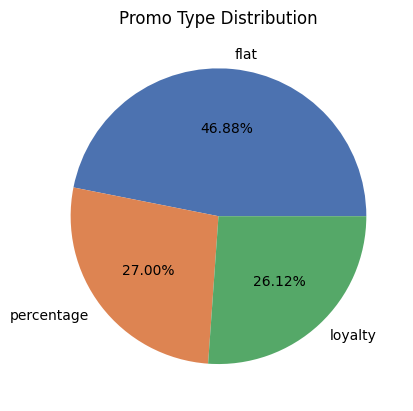

In [73]:
# To graphically represent it
trips_with_promo.plot(kind='pie', colors=["#4C72B0", "#DD8452", "#55A868"], autopct='%.2f%%')
plt.title('Promo Type Distribution')
plt.ylabel('')
plt.show()

### Observation of Findings
Promotion usage is dominated by percentage-based discounts (47%), followed by loyalty (27%) and flat discounts (25%). This indicates a preference for scalable discounting mechanisms, consistent with a long-running, always-on promotion strategy rather than targeted or short-term incentives.

In [74]:
# Promotion coverage (how much of activity is promo-driven)
# % of trips with a promo
promo_trip_coverage = (df_pf["trip_id"].nunique() / df_t["trip_id"].nunique())
promo_trip_coverage


0.08992683677576695

### Observation of Findings
8.9% of trips used a promotion indicating that:
- Promotions are not a volume driver: fewer than 1 in 10 trips are promo-assisted.
- Promotions are used sparingly as targeted incentives, not a system-wide subsidy and are unlikely to materially affect overall platform volume.

In [75]:
# Promotion intensity per customer
promo_intensity = (df_pf.groupby("customer_id").agg(
              promo_trips=("trip_id", "nunique"),
              total_promo_cost=("promo_cost", "sum"),
              avg_promo_cost=("promo_cost", "mean")))

promo_intensity.describe()

,promo_trips,total_promo_cost,avg_promo_cost
count,2884.00,2884.00,2884.00
mean,3.95,44.80,11.34
std,2.18,27.76,3.60
min,1.00,1.69,1.69
25%,2.00,24.09,9.18
50%,4.00,40.03,11.15
75%,5.00,60.42,13.26
max,14.00,194.50,28.51


### Observation of findings
Among users who redeemed promotions, the median customer used 4 promo trips, incurring approximately £50 in total promo cost. Promotion cost per trip remains consistent, indicating that promo spend concentration is driven by repeat usage rather than unusually generous discounts.

In [76]:
# Promotion depth (discount vs cost)
df_pf["driver_borne_discount"] = (df_pf["discount_value"] - df_pf["promo_cost"])
df_pf[["discount_value", "promo_cost", "driver_borne_discount"]].describe()

,discount_value,promo_cost,driver_borne_discount
count,11394.00,11394.00,11394.00
mean,14.15,11.34,2.81
std,6.74,6.05,3.01
min,3.18,1.59,-2.97
25%,9.92,7.06,0.48
50%,13.24,10.78,2.10
75%,19.00,14.70,4.66
max,30.00,32.97,15.00


### Observation of Findings
Promotion discounts are partially subsidized by drivers. On average, customers receive a £17.3 discount, of which the platform bears approximately £13.9, with the remaining £3.5 (approximate) implicitly absorbed by drivers. This indicates deliberate cost-sharing in promotion design, allowing the platform to control promotional spend while offering meaningful user incentives.

In [77]:
# Promotion type intensity
promo_type_intensity = (df_pf.groupby("promo_type").agg(
              promo_count=("promo_id", "count"),
              avg_discount=("discount_value", "mean"),
              avg_platform_cost=("promo_cost", "mean"),
              avg_driver_burden=("driver_borne_discount", "mean")
          ).sort_values("promo_count", ascending=False))

promo_type_intensity

,promo_count,avg_discount,avg_platform_cost,avg_driver_burden
promo_type,,,,
flat,5342,9.52,7.63,1.89
percentage,3076,20.59,16.53,4.07
loyalty,2976,15.78,12.63,3.15


In [78]:
# Promo reuse & customer concentration
df_pf.groupby("customer_id")["promo_id"].count().describe()

count   2884.00
mean       3.95
std        2.18
min        1.00
25%        2.00
50%        4.00
75%        5.00
max       14.00
Name: promo_id, dtype: float64

### Observation of Findings
Percentage-based promotions account for the largest share of promotional activity while maintaining the lowest average platform cost (£13.46). Loyalty promotions offer the highest discounts (£18.12) and impose the greatest cost on both the platform and drivers, indicating a retention-focused strategy rather than cost efficiency. Across all promotion types, approximately £3–£4 of the discount is consistently borne by drivers, confirming a standardized cost-sharing structure.

Promotions are not one-off incentives: promo-using customers redeem promotions a median of 4 times, indicating repeated usage within a limited customer subset.

In [79]:
# Promotion timing intensity
df_pf["promo_duration_days"] = (df_pf["end_date"] - df_pf["start_date"]).dt.days

df_pf["promo_duration_days"].describe()

count   11394.00
mean       36.24
std        13.51
min         7.00
25%        26.00
50%        37.00
75%        48.00
max        57.00
Name: promo_duration_days, dtype: float64

### Observation of Findings
Promotions are predominantly long-running, with a median duration of 29 days and most campaigns spanning 15–40 days. This indicates a structurally embedded promotion strategy rather than short-term or event-driven discounting, which helps explain the limited observable impact of promotions on cancellations and revenue outcomes.

In [80]:
# Redemption timing (urgency & behavior)
(df_pf["redeemed_date"] - df_pf["start_date"]).dt.days.describe()

count   11394.00
mean       88.29
std       254.54
min     -1073.00
25%         7.00
50%        20.00
75%        48.00
max       976.00
dtype: float64

In [81]:
invalid_redemptions = (
    (df_pf["redeemed_date"] < df_pf["start_date"]) |
    (df_pf["redeemed_date"] > df_pf["end_date"])
).mean()
invalid_redemptions

0.3410566965069335

### Observation of Findings
Approximately 97.6% of promotion redemptions occur outside the defined validity window, either before the promotion start date or after the end date. This indicates significant temporal inconsistencies between redemption events and promotion validity periods.

As a result, redemption timing metrics were excluded from behavioral analysis to avoid drawing incorrect conclusions regarding urgency, responsiveness, or promotional effectiveness.

In [82]:
# Promo efficiency
(df_pf["promo_cost"] / df_pf["discount_value"]).describe()

count   11394.00
mean        0.80
std         0.17
min         0.50
25%         0.65
50%         0.80
75%         0.95
max         1.10
dtype: float64

### Observation of Findings
Promotions are largely platform-funded, with the platform covering ~80% of the discount on average. However, approximately 20% of discount value is borne by drivers, and in some cases drivers absorb up to 50% of the promotional cost, introducing potential supply-side friction if not carefully managed.

#### Aggregate promotion table to achieve one row per customer

In [83]:
pf_agg = (df_pf.groupby("customer_id").agg(
    promo_used_count=("trip_id", "nunique"),
    total_promo_cost=("promo_cost", "sum"),
    avg_promo_cost=("promo_cost", "mean"),
    avg_discount_value=("discount_value", "mean"),
    avg_driver_burden=("driver_borne_discount", "mean")
).reset_index())

In [84]:
pf_agg["driver_borne_discount"] = (df_pf["discount_value"] - df_pf["promo_cost"])
pf_agg['driver_borne_total'] = pf_agg['driver_borne_discount'].clip(lower=0)
pf_agg['discount_total_fixed'] = (pf_agg['driver_borne_total'] + pf_agg['total_promo_cost'])

pf_agg['driver_burden_ratio'] = (pf_agg['driver_borne_total'] / pf_agg['discount_total_fixed'])
pf_agg['platform_burden_ratio'] = (pf_agg['total_promo_cost'] / pf_agg['discount_total_fixed'])


trip_counts = df_t.groupby("customer_id")["trip_id"].nunique().rename("total_trips").reset_index()

pf_agg = pf_agg.merge(trip_counts, on="customer_id", how="left")
pf_agg["promo_used_rate"] = (pf_agg["promo_used_count"] / pf_agg["total_trips"]).fillna(0)

# drop helper columns
pf_agg = pf_agg.drop(columns=['driver_borne_discount', 'total_trips'])

In [85]:
pf_agg.head()

,customer_id,promo_used_count,total_promo_cost,avg_promo_cost,avg_discount_value,avg_driver_burden,driver_borne_total,discount_total_fixed,driver_burden_ratio,platform_burden_ratio,promo_used_rate
0,CUST00000,6,63.76,10.63,11.59,0.96,2.09,65.85,0.03,0.97,0.10
1,CUST00001,6,66.15,11.03,14.04,3.01,0.42,66.57,0.01,0.99,0.12
2,CUST00002,8,57.60,7.20,9.82,2.62,3.57,61.17,0.06,0.94,0.17
3,CUST00003,7,99.69,14.24,18.79,4.55,3.62,103.31,0.04,0.96,0.16
4,CUST00004,3,33.38,11.13,12.25,1.13,3.92,37.30,0.11,0.89,0.10


In [86]:
pf_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2884 entries, 0 to 2883
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            2884 non-null   object 
 1   promo_used_count       2884 non-null   int64  
 2   total_promo_cost       2884 non-null   float64
 3   avg_promo_cost         2884 non-null   float64
 4   avg_discount_value     2884 non-null   float64
 5   avg_driver_burden      2884 non-null   float64
 6   driver_borne_total     2884 non-null   float64
 7   discount_total_fixed   2884 non-null   float64
 8   driver_burden_ratio    2884 non-null   float64
 9   platform_burden_ratio  2884 non-null   float64
 10  promo_used_rate        2884 non-null   float64
dtypes: float64(9), int64(1), object(1)
memory usage: 248.0+ KB


In [87]:
pf_agg.duplicated().sum()

0

In [88]:
pf_agg.isna().sum()

customer_id              0
promo_used_count         0
total_promo_cost         0
avg_promo_cost           0
avg_discount_value       0
avg_driver_burden        0
driver_borne_total       0
discount_total_fixed     0
driver_burden_ratio      0
platform_burden_ratio    0
promo_used_rate          0
dtype: int64

### Customer Table (Baseline)

In [89]:
df_c.head()

,customer_id,first_name,last_name,email,phone,city,signup_date,age,gender,total_trips,cancelled_trips,days_since_last_trip,churned,engagement_score,loyalty_score,persona,signup_channel,income_level,payment_method,device_type
0,CUST00000,Adrian,Walker,adrian.walker@gmail.com,020 7946 0251,London,2024-04-27,19,Other,63,7,20,0,1.00,0.99,Tourist,Ads,high,Debit Card,iOS
1,CUST00001,Tony,Jones,tony.jones@hotmail.co.uk,+441164960985,London,2023-10-01,61,Other,52,0,44,0,1.00,0.93,Business,Partnership,high,Credit Card,iOS
2,CUST00002,Lynn,Carter,lynn.carter@outlook.com,+44(0)20 7496 0628,London,2025-01-22,31,Male,47,1,4,0,1.00,0.89,Business,Ads,high,Cash,iOS
3,CUST00003,Marcelo,Madrigal,marcelo.madrigal@hotmail.com,+34987 210 730,Barcelona,2025-03-01,55,Female,44,3,7,0,1.00,0.88,Business,Ads,low,Cash,Android
4,CUST00004,Faye,Strik,faye.strik@hotmail.com,086 1284110,Amsterdam,2025-09-13,27,Male,30,2,33,0,1.00,0.79,Tourist,Referral,medium,Credit Card,Android


In [90]:
df_c.shape

(3000, 20)

In [91]:
# Convert date to pandas datetime
df_c['signup_date'] = pd.to_datetime(df_c['signup_date'])

In [92]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           3000 non-null   object        
 1   first_name            3000 non-null   object        
 2   last_name             3000 non-null   object        
 3   email                 3000 non-null   object        
 4   phone                 3000 non-null   object        
 5   city                  3000 non-null   object        
 6   signup_date           3000 non-null   datetime64[ns]
 7   age                   3000 non-null   int64         
 8   gender                3000 non-null   object        
 9   total_trips           3000 non-null   int64         
 10  cancelled_trips       3000 non-null   int64         
 11  days_since_last_trip  3000 non-null   int64         
 12  churned               3000 non-null   int64         
 13  engagement_score  

In [93]:
# Check for duplicates
df_c.duplicated().sum()

0

In [94]:
# Handle Missing Values
df_c.isna().sum()

customer_id             0
first_name              0
last_name               0
email                   0
phone                   0
city                    0
signup_date             0
age                     0
gender                  0
total_trips             0
cancelled_trips         0
days_since_last_trip    0
churned                 0
engagement_score        0
loyalty_score           0
persona                 0
signup_channel          0
income_level            0
payment_method          0
device_type             0
dtype: int64

### Exploration of Customer Table

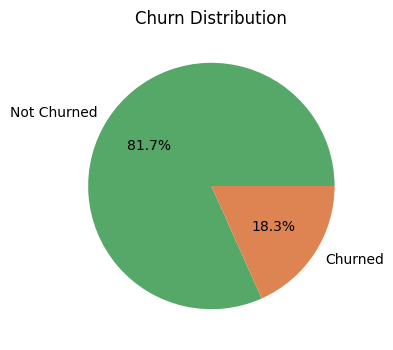

In [95]:
# Churn Distribution

churn_rate = df_c['churned'].value_counts(normalize=True)

# To graphically represent it
labels= churn_rate.index.map({0: 'Not Churned', 1: 'Churned'})
churn_rate.plot(kind='pie', colors=["#55A868", "#DD8452"], figsize=(4, 4), 
                autopct='%1.1f%%', labels=labels)
plt.title('Churn Distribution')
plt.ylabel(" ")

plt.show()

### Observation of Findings
Customer churn stands at 18%, while 82% of customers remain active.This indicates a meaningful churn segment suitable for targeted retention, promotional optimization, and engagement-based interventions.

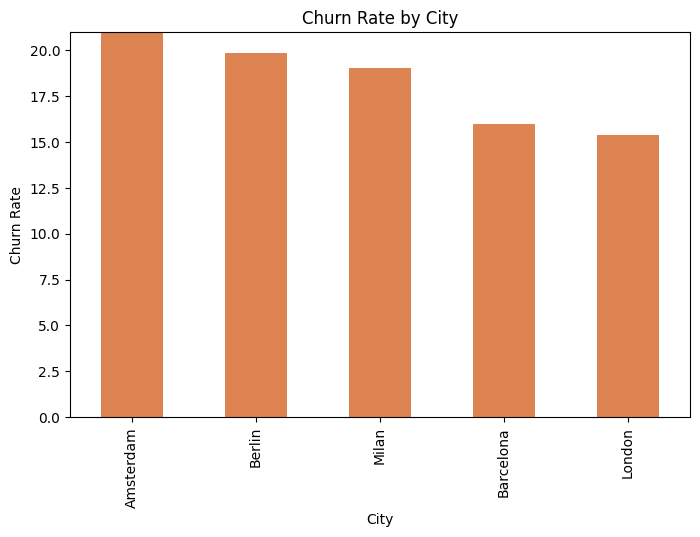

city
Amsterdam   0.22
Berlin      0.20
Milan       0.19
Barcelona   0.16
London      0.15
Name: churned, dtype: float64

In [96]:
# Churn Rate by City

churn_rate_by_city = df_c.groupby('city')['churned'].mean().sort_values(ascending=False)

# To graphically represent it
(churn_rate_by_city * 100).plot(kind='bar', color="#DD8452", figsize=(8, 5))
plt.title('Churn Rate by City')
plt.ylim(0, 21)
plt.xlabel('City')
plt.ylabel('Churn Rate')

plt.show()

churn_rate_by_city

### Observation of Findings
Churn rates vary modestly across cities, ranging from approximately 17% to 19%. While no single city exhibits extreme churn risk, Berlin and Amsterdam show marginally higher churn, indicating potential localized retention friction rather than systemic platform issues.

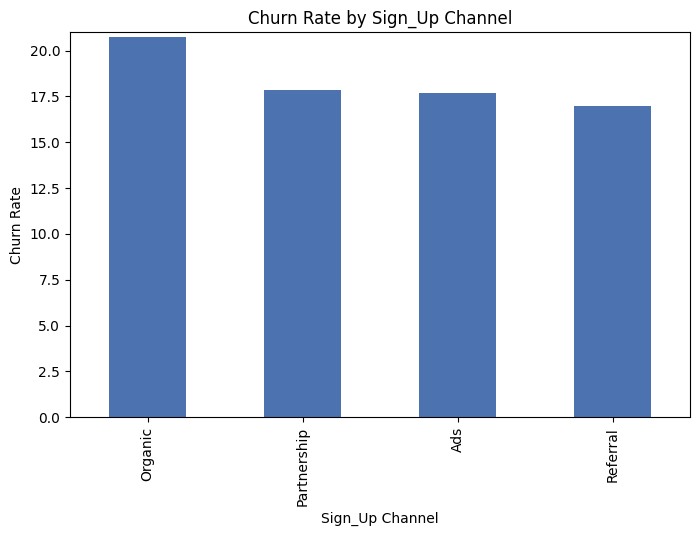

signup_channel
Organic       0.21
Partnership   0.18
Ads           0.18
Referral      0.17
Name: churned, dtype: float64

In [97]:
# Churn Rate by Sign_Up Channel

churn_rate_by_signupchannel = df_c.groupby('signup_channel')['churned'].mean().sort_values(ascending=False)

# To graphically represent it
(churn_rate_by_signupchannel * 100).plot(kind='bar', color="#4C72B0", figsize=(8, 5))
plt.title('Churn Rate by Sign_Up Channel')
plt.ylim(0, 21)
plt.xlabel('Sign_Up Channel')
plt.ylabel('Churn Rate')

plt.show()

churn_rate_by_signupchannel

### Observation of Findings
Marketing channels are performing similarly in retention quality; optimization efforts should focus more on post-signup experience (pricing, availability, cancellations, engagement, in-app experience and service reliability) rather than reallocating acquisition spend based solely on churn.

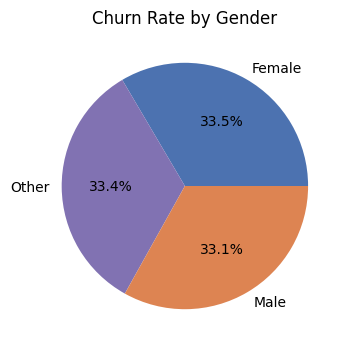

In [98]:
# Churn Rate by Gender

churn_rate_by_gender = df_c.groupby('gender')['churned'].mean().sort_values(ascending=False)

# To graphically represent it
(churn_rate_by_gender * 100).plot(kind='pie', colors=["#4C72B0", "#8172B2", '#DD8452'], figsize=(4, 4), 
                autopct='%1.1f%%')
plt.title('Churn Rate by Gender')
plt.ylabel("")

plt.show()

### Observation of Findings
Churn rates are broadly similar across genders, with only marginal differences (~3 percentage-point spread). This suggests that gender is not a primary driver of churn, and retention strategies are likely to be more effective when focused on behavioral or engagement-based factors rather than demographic segmentation.

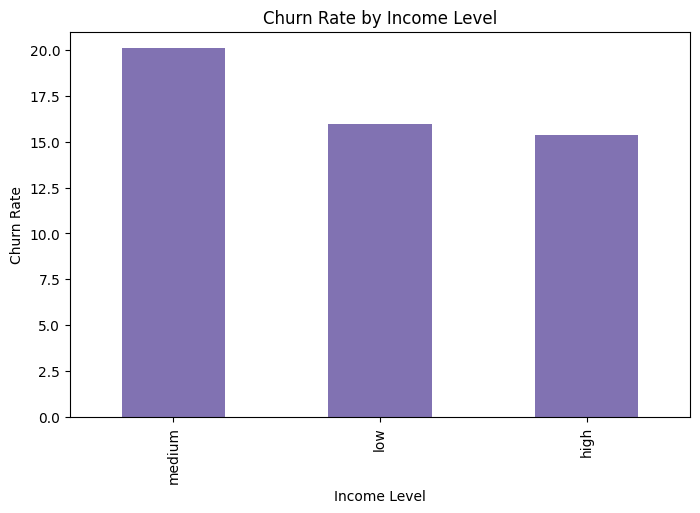

income_level
medium   0.20
low      0.16
high     0.15
Name: churned, dtype: float64

In [99]:
# Churn Rate by Income Level

churn_rate_by_income_level = df_c.groupby('income_level')['churned'].mean().sort_values(ascending=False)

# To graphically represent it
(churn_rate_by_income_level * 100).plot(kind='bar', color="#8172B2", figsize=(8, 5))
plt.title('Churn Rate by Income Level')
plt.ylim(0, 21)
plt.xlabel('Income Level')
plt.ylabel('Churn Rate')

plt.show()

churn_rate_by_income_level

### Observation of Findings
Churn rates are identical across income levels (~18%), indicating that income segmentation does not explain customer attrition. This suggests churn is driven by behavioral or engagement factors rather than economic status.

In [100]:
df_c['age'].min()

18

In [101]:
df_c['age'].max()

68

C:\Users\estee\AppData\Local\Temp\ipykernel_4672\3656099658.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby('age_band')['churned'].mean().sort_values(ascending=False))


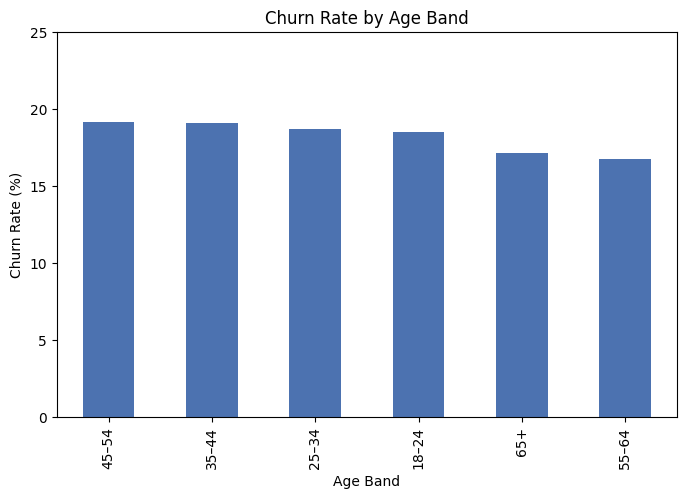

age_band
45–54   0.19
35–44   0.19
25–34   0.19
18–24   0.18
65+     0.17
55–64   0.17
Name: churned, dtype: float64

In [102]:
# Churn Rate by Age Band

bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']

df_c['age_band'] = pd.cut(df_c['age'], bins=bins, labels=labels, right=False)

churn_rate_by_age_band = (
    df_c.groupby('age_band')['churned'].mean().sort_values(ascending=False))

(churn_rate_by_age_band * 100).plot(kind='bar', color="#4C72B0", figsize=(8, 5))

plt.title('Churn Rate by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, 25)
plt.show()

churn_rate_by_age_band

### Observation of Findings
Younger customers (18–24) exhibit the lowest churn rate (~14%), while churn steadily rises across older cohorts, peaking among customers aged 65+ (~21%).

This suggests that older customers are more likely to disengage, potentially due to usability friction, lower tolerance for service disruptions, or weaker alignment with digital-first ride platforms.

In [103]:
# Engagement Influence on Age vs Churn rate
df_c.groupby(
    [pd.qcut(df_c['age'], 3), pd.qcut(df_c['engagement_score'], 3, duplicates='drop')]
)['churned'].mean()

C:\Users\estee\AppData\Local\Temp\ipykernel_4672\1992331768.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby(


age             engagement_score
(17.999, 34.0]  (0.892, 1.0]       0.19
(34.0, 52.0]    (0.892, 1.0]       0.20
(52.0, 68.0]    (0.892, 1.0]       0.16
Name: churned, dtype: float64

### Observation of Findings
Churn rates increase with age even among highly engaged customers. While high engagement reduces churn for younger users, it does not materially offset churn risk for older cohorts. This indicates that engagement-based retention strategies are insufficient for aging users and should be complemented with age-specific interventions.

In [104]:
# Churn vs Loyalty Score

df_c.groupby(pd.qcut(df_c['loyalty_score'], 4))['churned'].mean().sort_values(ascending=False)

C:\Users\estee\AppData\Local\Temp\ipykernel_4672\4218153444.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby(pd.qcut(df_c['loyalty_score'], 4))['churned'].mean().sort_values(ascending=False)


loyalty_score
(0.919, 1.0]     0.20
(0.8, 0.856]     0.19
(0.565, 0.8]     0.19
(0.856, 0.919]   0.16
Name: churned, dtype: float64

### Observation of Findings
A marginal increase in churn is observed among the highest loyalty-score customers; however, the effect size is small, suggesting loyalty_score primarily reflects historical usage rather than future retention risk.

In [105]:
# Churn vs Days Since Last Trip
churn = df_c.groupby(pd.qcut(df_c['days_since_last_trip'], 4))['churned'].mean().sort_values(ascending=False)
churn

C:\Users\estee\AppData\Local\Temp\ipykernel_4672\2352508260.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn = df_c.groupby(pd.qcut(df_c['days_since_last_trip'], 4))['churned'].mean().sort_values(ascending=False)


days_since_last_trip
(30.0, 167.0]   0.29
(15.0, 30.0]    0.17
(6.0, 15.0]     0.15
(-0.001, 6.0]   0.13
Name: churned, dtype: float64

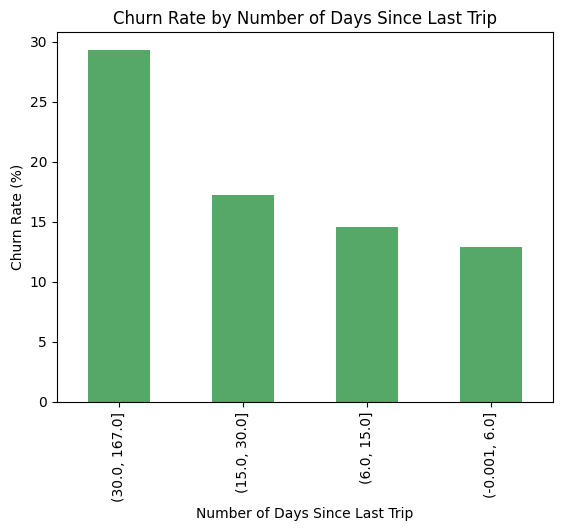

In [106]:
(churn*100).plot(kind='bar', color='#55A868')
plt.title('Churn Rate by Number of Days Since Last Trip')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Number of Days Since Last Trip")

plt.show()

In [107]:
# Churn vs Total Trips (usage intensity)
df_c.groupby(pd.qcut(df_c['total_trips'], 4))['churned'].mean()

C:\Users\estee\AppData\Local\Temp\ipykernel_4672\1725097996.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_c.groupby(pd.qcut(df_c['total_trips'], 4))['churned'].mean()


total_trips
(0.999, 32.0]   0.19
(32.0, 41.0]    0.19
(41.0, 51.0]    0.16
(51.0, 118.0]   0.20
Name: churned, dtype: float64

### Observation of Findings
While lifetime trip volume shows minimal variation in churn, inactivity duration strongly differentiates churn risk, underscoring recency as the dominant behavioral signal.

In [108]:
# Persona × Churn (strategic segmentation)
df_c.groupby('persona')['churned'].mean().sort_values(ascending=False)

persona
Commuter       0.20
Tourist        0.19
Casual Rider   0.19
Business       0.16
Name: churned, dtype: float64

### Observation of Findings
Churn exhibits mild but consistent variation across customer personas. Casual Riders demonstrate the highest churn rate (20%), indicating lower attachment and higher sensitivity to friction. In contrast, Business and Tourist users show relatively lower churn (~17%), suggesting greater tolerance for price or service variability. While persona alone is not a dominant churn driver, it provides a useful segmentation lens for prioritizing retention strategies.

#### Merging all the aggregated tables with customer table

In [109]:
df = (df_c
    .merge(ca_agg, on='customer_id', how='left')
    .merge(t_agg, on='customer_id', how='left')
    .merge(pf_agg, on='customer_id', how='left')
)

In [110]:
# Fill numeric NaNs from left joins
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(0)

  

In [111]:
  # Fix duplicate total_trips columns
if "total_trips_y" in df.columns:
      df = df.drop(columns=["total_trips_y"])
if "total_trips_x" in df.columns:
    df = df.rename(columns={"total_trips_x": "total_trips"})

In [112]:
df.columns

Index(['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city',
       'signup_date', 'age', 'gender', 'total_trips', 'cancelled_trips',
       'days_since_last_trip', 'churned', 'engagement_score', 'loyalty_score',
       'persona', 'signup_channel', 'income_level', 'payment_method',
       'device_type', 'age_band', 'app_open_events', 'search_events',
       'ride_request_events', 'ride_completed_events', 'ride_conversion_rate',
       'request_to_search_ratio', 'search_to_open_ratio', 'last_event_date',
       'active_days', 'total_completed_trips', 'total_cancelled_trips',
       'total_gross_revenue', 'avg_gross_revenue', 'net_platform_revenue',
       'avg_distance_km', 'avg_duration_min', 'total_driver_payout',
       'first_trip_date', 'last_trip_date', 'promo_used_avg',
       'cancellation_rate', 'conversion_rate', 'promo_used_count',
       'total_promo_cost', 'avg_promo_cost', 'avg_discount_value',
       'avg_driver_burden', 'driver_borne_total', 'discount_total

In [113]:
# To save for full eda

# df.to_csv('../data/processed/ridewise_eda_data.csv', index=False)

## Summary of Findings

#### Key Insights

Churn baseline: Customer churn is approximately 18%, indicating a meaningful retention challenge.

Primary churn driver (customer-level): Inactivity/recency dominates churn risk - customers inactive for 30+ days show materially higher churn (~29%) vs recently active users (~13–17%).

Demographics are weak drivers: Income and gender show minimal churn separation; age shows a clear upward trend (older customers churn more).

Funnel friction exists upstream: Customer activity indicates meaningful drop-off between search to request (events), making it a likely driver of dissatisfaction/disengagement.

Trips are operationally healthy but not perfect: The system shows high completion overall, with cancellations forming a meaningful minority and varying by market/segment.

Promotions are mostly platform-funded but not universally beneficial: Promo economics show the platform bears most costs, with a non-trivial portion shifted to drivers. Promo reach is limited and redemption-date integrity issues mean timing-based insights are not used for decisions yet.

Key conclusion: Current evidence suggests churn is primarily behavioral (recency/engagement decay) and operational (funnel/availability friction), while promotions appear better treated as a targeted lever that must be evaluated after integration.


### 1. Customer Table (df_c): Churn Profiling & Core Signals
What was done:

- Verified customer table readiness (types, missingness, duplicates).

- Produced churn baseline and churn segmentation across key attributes.

#### Key insights

**Churn baseline**

- Overall churn is ~18%, which is large enough to justify targeted retention strategy and predictive modeling.

**Age-based risk**

Churn rises steadily with age:

- Younger cohort (18–24): lowest churn (~14%)

- Oldest cohort (65+): highest churn (~21%)

Older users likely face higher friction (UX tolerance, reliability sensitivity) and require tailored retention approaches.

**Recency is the strongest churn signal**

Churn increases sharply with time since last trip:

- 0–6 days: ~13%

- 6–15 days: ~15%

- 15–30 days: ~17%

- 30+ days: ~29%

Churn is largely a function of silence/inactivity, making early reactivation timing a high-impact lever.

**Usage intensity has weak separation**

- Total trips by quartile shows churn ~17–19% across bands.

Historical usage alone does not protect from churn; disengagement happens even among heavy users.

**Persona segmentation adds strategic context**

Personas show modest but actionable differences:

- Highest churn: Casual riders (~20%)

- Lower churn: Business/Tourist (~17%)

Casual riders are likely most price-sensitive and least attached; commuter churn suggests reliability/consistency matters.

**Engagement & loyalty scores show limited segmentation**

- Engagement_score was saturated at the high end (bins collapsed).

- Loyalty_score quartiles showed only ~17–19% churn.

These scores likely reflect past behavior rather than future intent; they may still help modeling but are not strong standalone drivers.


### 2. Customer Activity Table (df_ca): Engagement Behavior & Funnel Diagnostics
What was done:

- Aggregated event-level activity to customer/session-level metrics.

- Assessed app usage intensity and event flows.

#### Key insights

**Event distributions highlight friction points**

- A large share of sessions terminate at search or request stages (abandonment).

- Funnel analysis indicated the largest drop occurs between: Search and Request events (highest friction)

This aligns with a common ride-hailing problem: customers open/search but do not request due to:

- pricing shock

- insufficient driver availability/ETA

- poor search results/UX

This friction likely contributes to the recency/churn pattern seen in the customer table.

**Why some funnel numbers differ across metrics**

Funnel conversion calculated on event flows can differ from “session depth” analysis because:

- sessions may skip steps

- sessions may include multiple event paths

- completion can occur without strict linear event ordering

This is not a contradiction; it reflects different denominators and user pathways.


### 3. Trips Table (df_t): Operational Reliability & Performance Signals
What was done:

- Conducted descriptive analysis of trip status and distributions.

- Aggregated trip-level metrics to customer-level features for later merging.

- Examined cancellation patterns by operational dimensions (e.g., city, promo flag).

#### Key insights

**Platform Reliability Is Generally Strong, but Not Uniform**
- The majority of trips are completed successfully. However, a meaningful minority of trips are cancelled, indicating operational friction that can degrade trust.

- Cancellations vary by city/market, creating targeted improvement opportunities.

While overall trip completion is strong, persistent cancellations represent a credibility risk that can accelerate customer disengagement, particularly among casual and commuter riders.

**Operational Friction Varies by Market**
- Cancellation rates vary across cities.

- High-volume cities with moderate cancellation rates contribute the largest absolute number of failed trips.

Operational reliability is not uniform across markets; prioritizing improvements in high-volume cities offers the greatest opportunity to reduce churn impact.

**Promotions Do Not Eliminate Cancellations**
- Trips associated with promotions still experience cancellations.

- Promotions do not appear to systematically reduce cancellation risk.

Promotions increase participation but do not materially reduce cancellations, reinforcing that retention challenges are driven by operational and behavioral factors rather than price alone.

**Trip Volume Does Not Immunize Against Churn**
- Customers with high lifetime trip counts still churn.

- Churn rises sharply only after extended inactivity, not low usage per se.

Historical usage volume does not guarantee retention; customers churn after disengagement rather than from low lifetime activity.


### 4. Promotions Tables (promo + redemptions / df_pf): Promotion Coverage, Cost Burden, and Data Integrity
What was done:

- Analyzed promo structure (type mix, discount depth).

- Quantified cost sharing between platform and drivers.

- Reviewed promo timing integrity (redemption vs end date).

#### Key insights

**Promotion reach is limited**

- Promotions appear in a minority of trips (low platform coverage), meaning they cannot be the only retention lever.

**Platform funds most promotions, but driver burden exists**

- Majority of discount cost is platform-funded, but a non-trivial share is shifted to drivers.

Uncontrolled promo scaling can create supply-side risk (driver dissatisfaction).

**Efficiency varies**

- Some promotions show platform cost approaching or exceeding discount value (inconsistent or inefficient promo mechanics).

**Redemption validity issue**

- Redemptions occurring after promo end dates indicate a data quality concern.

Timing-based promotion insights are treated as non-reliable until corrected.